Importing important libreries

In [ ]:
import numpy as np
import pandas as pd
import joblib as jb

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor 
from xgboost import XGBRegressor
# from sklearn.feature_selection import SelectKBest,chi2

In [1014]:
df = pd.read_csv(r"C:\Users\manis\OneDrive\Desktop\House-Price-Prediction\data\house_prices.csv")

Data Cleaning And Feature Engineering


In [1015]:
df.head(1)

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN


In [1016]:
df.drop(columns=["Index","Description","Plot Area","Dimensions","Super Area", "Car Parking", "Society", "Status"], inplace=True)

In [1017]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Title              187531 non-null  object 
 1   Amount(in rupees)  187531 non-null  object 
 2   Price (in rupees)  169866 non-null  float64
 3   location           187531 non-null  object 
 4   Carpet Area        106858 non-null  object 
 5   Floor              180454 non-null  object 
 6   Transaction        187448 non-null  object 
 7   Furnishing         184634 non-null  object 
 8   facing             117298 non-null  object 
 9   overlooking        106095 non-null  object 
 10  Bathroom           186703 non-null  object 
 11  Balcony            138596 non-null  object 
 12  Ownership          122014 non-null  object 
dtypes: float64(1), object(12)
memory usage: 18.6+ MB


In [1018]:
# Total persantage of duplicates
int(df.duplicated().sum())*100/df.shape[0]

64.27257360116461

In [1019]:
df[df.duplicated()]

,Title,Amount(in rupees),Price (in rupees),location,Carpet Area,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Ownership
228,4 BHK Ready to Occupy Flat for sale in Hiranan...,3.20 Cr,17827.0,thane,1350 sqft,16 out of 27,Resale,Unfurnished,East,Garden/Park,3,1,Freehold
453,2 BHK Ready to Occupy Flat for sale in Cosmos ...,1 Cr,9091.0,thane,NaN,8 out of 27,New Property,Semi-Furnished,NaN,NaN,2,NaN,NaN
459,1 BHK Ready to Occupy Flat for sale Kasarvadavali,38 Lac,8837.0,thane,NaN,4 out of 7,Resale,Unfurnished,NaN,NaN,1,NaN,NaN
494,2 BHK Ready to Occupy Flat for sale in Cosmos ...,1 Cr,9091.0,thane,NaN,8 out of 27,New Property,Semi-Furnished,NaN,NaN,2,NaN,NaN
495,2 BHK Ready to Occupy Flat for sale in Cosmos ...,1 Cr,9091.0,thane,NaN,8 out of 27,New Property,Semi-Furnished,NaN,NaN,2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187422,3 BHK Ready to Occupy Flat for sale Ambala Hig...,63.9 Lac,3277.0,zirakpur,1350 sqft,2 out of 4,New Property,Semi-Furnished,North - East,"Garden/Park, Pool, Main Road",3,2,Freehold
187423,3 BHK Ready to Occupy Flat for sale Ambala Hig...,63.9 Lac,3277.0,zirakpur,1350 sqft,2 out of 4,New Property,Semi-Furnished,North - East,"Garden/Park, Pool, Main Road",3,2,Freehold
187424,3 BHK Ready to Occupy Flat for sale in Elanza ...,73.9 Lac,4322.0,zirakpur,900 sqft,2 out of 4,New Property,Semi-Furnished,East,"Garden/Park, Main Road",3,2,Freehold
187482,3 BHK Ready to Occupy Flat for sale in Highlan...,52.9 Lac,3833.0,zirakpur,NaN,3 out of 3,New Property,Semi-Furnished,East,Garden/Park,3,2,Freehold


In [1020]:
df.drop_duplicates(inplace=True)

In [1021]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67000 entries, 0 to 187530
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              67000 non-null  object 
 1   Amount(in rupees)  67000 non-null  object 
 2   Price (in rupees)  61181 non-null  float64
 3   location           67000 non-null  object 
 4   Carpet Area        37484 non-null  object 
 5   Floor              64501 non-null  object 
 6   Transaction        66922 non-null  object 
 7   Furnishing         65736 non-null  object 
 8   facing             40642 non-null  object 
 9   overlooking        37948 non-null  object 
 10  Bathroom           66550 non-null  object 
 11  Balcony            48336 non-null  object 
 12  Ownership          42486 non-null  object 
dtypes: float64(1), object(12)
memory usage: 7.2+ MB


In [1022]:

df["location"].nunique()

81

In [1023]:
df.head(1)

,Title,Amount(in rupees),Price (in rupees),location,Carpet Area,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Ownership
0,1 BHK Ready to Occupy Flat for sale in Srushti...,42 Lac,6000.0,thane,500 sqft,10 out of 11,Resale,Unfurnished,NaN,NaN,1,2,NaN


In [1024]:
(df.isnull().sum()/df.shape[0])*100

Title                 0.000000
Amount(in rupees)     0.000000
Price (in rupees)     8.685075
location              0.000000
Carpet Area          44.053731
Floor                 3.729851
Transaction           0.116418
Furnishing            1.886567
facing               39.340299
overlooking          43.361194
Bathroom              0.671642
Balcony              27.856716
Ownership            36.588060
dtype: float64

In [1025]:
df["Ownership"].value_counts()

Ownership
Freehold                36610
Leasehold                3030
Co-operative Society     2365
Power Of Attorney         481
Name: count, dtype: int64

In [1026]:
df["Transaction"].unique()

array(['Resale', 'New Property', nan, 'Other', 'Rent/Lease'], dtype=object)

In [1027]:
df["Bhk"] = df["Title"].str.split(" ").str[0]
df["Bhk"] = pd.to_numeric(df["Bhk"], errors="coerce")

In [1028]:
df["Carpet value"] = df["Carpet Area"].str.split(" ").str[1]

In [1029]:
df["Carpet value"].unique()

array(['sqft', nan, 'sqm', 'sqyrd', 'acre', 'ground', 'cent', 'bigha',
       'marla', 'kanal'], dtype=object)

In [1030]:
conversion = {
    'sqft': 1,
    'sqm': 10.7639,
    'sqyrd': 9,
    'acre': 43560,
    'ground': 2400,
    'cent': 435.6,
    'bigha': 27225,
    'marla': 272.25,
    'kanal': 5445
}

df["Carpet_area_sqft"] = (
    pd.to_numeric(
        df["Carpet Area"].str.split().str[0],
        errors="coerce"
    )
    * df["Carpet value"].map(conversion)
)
df.drop(columns=["Carpet Area","Carpet value"], inplace=True)

In [1031]:
df["amount value"] = df["Amount(in rupees)"].str.split(" ").str[1]

In [1032]:
df["amount value"].unique()

array(['Lac', 'Cr', 'for'], dtype=object)

In [1033]:
# we have null values but its name is "call for value " so i am converting it into nan
df["amount value"] = df["amount value"].str.title()

df["amount value"] = df["amount value"].replace(
    "For",
    np.nan
)

In [1034]:
df["amount value"].unique()

array(['Lac', 'Cr', nan], dtype=object)

In [1035]:
# we have null values but its name is "call for value " so i am converting it into nan
df["Amount(in rupees)"] = df["Amount(in rupees)"].str.title()

df["Amount(in rupees)"] = df["Amount(in rupees)"].replace(
    "Call For Price",
    np.nan
)

In [1036]:
df.isnull().sum()/df.shape[0]*100


Title                 0.000000
Amount(in rupees)     4.294030
Price (in rupees)     8.685075
location              0.000000
Floor                 3.729851
Transaction           0.116418
Furnishing            1.886567
facing               39.340299
overlooking          43.361194
Bathroom              0.671642
Balcony              27.856716
Ownership            36.588060
Bhk                   0.523881
Carpet_area_sqft     44.053731
amount value          4.294030
dtype: float64

In [1037]:
parts = df["Amount(in rupees)"].str.lower().str.split()

df["Amount(in rupees)"] = (
    pd.to_numeric(parts.str[0], errors="coerce")
    * parts.str[1].map({
        "cr": 10000000,
        "lac": 100000,
        "lakh": 100000
    })
)



In [1038]:
df.loc[df["Floor"] == "Ground", "Floor"] = "0 out of 0"
df["Floor"] = df["Floor"].str.capitalize().str.replace("Ground","0")
df["Floor"] = df["Floor"].str.capitalize().str.replace("Lower Basement","-2")
df["Floor"] = df["Floor"].str.capitalize().str.replace("Upper Basement","-1")
df["Floor"] = df["Floor"].str.capitalize().str.replace("Upper Ground","0.5")

df["Current_floor"] = df["Floor"].str.split().str[0]
df["Total_floor"] = df["Floor"].str.split().str[3]
#df.drop(columns=["Floor"], inplace=True)
df["overlooking"] = df["overlooking"].str.capitalize()

In [1039]:
df["Bathroom"].unique()

array(['1', '2', '3', '4', '6', nan, '5', '10', '9', '8', '> 10', '7'],
      dtype=object)

In [1040]:
(df["Bathroom"] == "> 10").sum()



np.int64(32)

In [1041]:
(df["Balcony"] == "> 10").sum()

np.int64(18)

In [1042]:
#In bathroom column there are 32 values having ">10" so to preserve actual meaning i am converting it to 11
#In bathroom balcony there are 18 values having ">10" so to preserve actual meaning i am converting it to 11

df["Bathroom"] = df["Bathroom"].replace("> 10", "11")
df["Balcony"] = df["Balcony"].replace("> 10", "11")

In [1043]:
df["Balcony"].unique()

array(['2', nan, '1', '3', '4', '11', '6', '5', '7', '10', '8', '9'],
      dtype=object)

In [1044]:
cols = ["Bathroom", "Balcony", "Bhk", "Current_floor", "Total_floor"]

df[cols] = df[cols].apply(pd.to_numeric, errors="coerce").astype(float)

In [1045]:
# Price (in rupees)  is aproxiate price per sqft so in this project it can lead to data leakage so i am removing this 

df.drop(columns=["amount value","Price (in rupees)"], inplace=True)

EDA


In [1046]:
(df.isnull().sum()/df.shape[0])*100

Title                 0.000000
Amount(in rupees)     4.294030
location              0.000000
Floor                 3.729851
Transaction           0.116418
Furnishing            1.886567
facing               39.340299
overlooking          43.361194
Bathroom              0.671642
Balcony              27.856716
Ownership            36.588060
Bhk                   0.523881
Carpet_area_sqft     44.053731
Current_floor         4.243284
Total_floor           4.307463
dtype: float64

Target Variable Cleaning

Missing values were found in the target column (`price`). These rows were dropped because target values should not be imputed in a regression problem.

In [1047]:
df = df.dropna(subset=["Amount(in rupees)"])

# Outliers removel greter then 99TH persentile

In [1048]:
# Step 1: Price filter
price_limit = df["Amount(in rupees)"].quantile(0.99)
df = df[df["Amount(in rupees)"] <= price_limit]

# Step 2: Carpet Area filter
area_limit = df["Carpet_area_sqft"].quantile(0.99)
df = df[df["Carpet_area_sqft"] <= area_limit]

total_floor_limit = df["Total_floor"].quantile(0.99)
df = df[df["Total_floor"] <= total_floor_limit]


In [1049]:
X = df.drop("Amount(in rupees)", axis=1)
y = (df["Amount(in rupees)"])



In [1050]:
# Top 2 values of carpet area  are 4.4e7 and 6.5e7 and these values are extrrmly high and seems precticaly imposible so i am removing top 2
X.nlargest(4, 'Total_floor')

,Title,location,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Ownership,Bhk,Carpet_area_sqft,Current_floor,Total_floor
76,3 BHK Ready to Occupy Flat for sale in Tata Se...,thane,20 out of 32,New Property,Unfurnished,East,Garden/park,3.0,1.0,Freehold,3.0,1168.0,20.0,32.0
164,2 BHK Ready to Occupy Flat for sale in Acura M...,thane,14 out of 32,Resale,Unfurnished,East,"Garden/park, main road",2.0,1.0,Freehold,2.0,640.0,14.0,32.0
166,2 BHK Ready to Occupy Flat for sale in Acura M...,thane,15 out of 32,Resale,Unfurnished,East,"Garden/park, main road",2.0,1.0,Freehold,2.0,640.0,15.0,32.0
170,3 BHK Ready to Occupy Flat for sale in Auralis...,thane,28 out of 32,New Property,Unfurnished,East,"Garden/park, main road",3.0,3.0,Freehold,3.0,1153.0,28.0,32.0


In [1051]:
# highest building in india has 88 floor so floor like 200,150 are suspicious and might be data error so i am removing it
X.nlargest(2, "Carpet_area_sqft")

,Title,location,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Ownership,Bhk,Carpet_area_sqft,Current_floor,Total_floor
50526,4 BHK Ready to Occupy Flat for sale in HUDA Au...,gurgaon,3 out of 4,New Property,Semi-Furnished,North - West,NaN,4.0,3.0,Freehold,4.0,3550.0,3.0,4.0
50717,4 BHK Ready to Occupy Flat for sale in Luxury ...,gurgaon,1 out of 4,New Property,Semi-Furnished,North - East,"Garden/park, main road",5.0,2.0,Freehold,4.0,3550.0,1.0,4.0


In [1052]:
X= X.drop(columns=["Title","Floor"])

In [1053]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34346 entries, 0 to 187528
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   location          34346 non-null  object 
 1   Transaction       34296 non-null  object 
 2   Furnishing        34325 non-null  object 
 3   facing            27513 non-null  object 
 4   overlooking       25870 non-null  object 
 5   Bathroom          34334 non-null  float64
 6   Balcony           32154 non-null  float64
 7   Ownership         28423 non-null  object 
 8   Bhk               34214 non-null  float64
 9   Carpet_area_sqft  34346 non-null  float64
 10  Current_floor     34346 non-null  float64
 11  Total_floor       34346 non-null  float64
dtypes: float64(6), object(6)
memory usage: 3.4+ MB


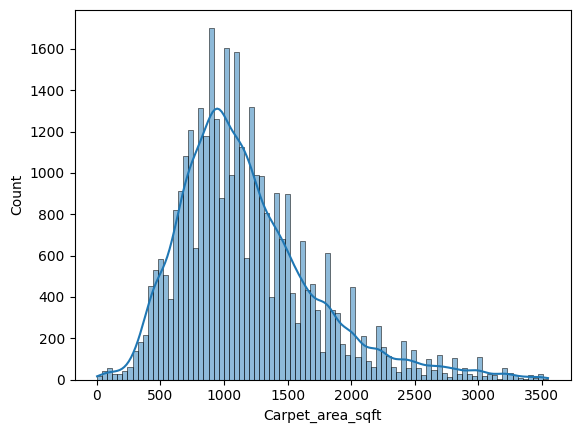

In [1054]:

sns.histplot(X["Carpet_area_sqft"],kde=True)
plt.show()

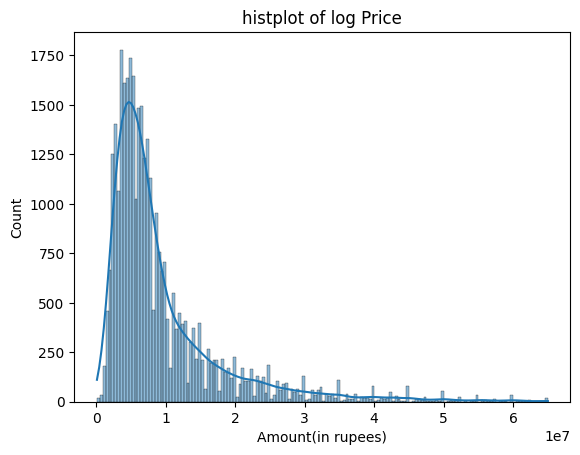

In [1055]:
sns.histplot((y), kde=True)
plt.title("histplot of log Price")
plt.show()

In [1056]:
arr = X["Current_floor"].unique()
arr.sort()
print(arr)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32.]


In [1057]:
arr = X["Total_floor"].unique()
arr.sort()
print(arr)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32.]


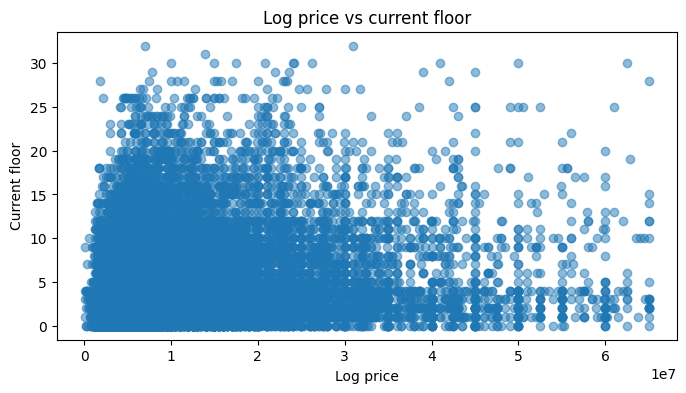

In [1058]:
plt.figure(figsize=(8,4))
plt.scatter(y,X["Current_floor"], alpha= 0.5 )
plt.title("Log price vs current floor")
plt.xlabel("Log price")
plt.ylabel("Current floor")
plt.show()

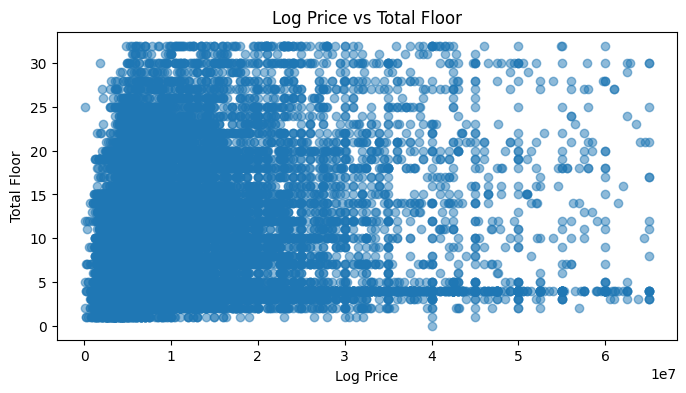

In [1059]:
plt.figure(figsize=(8,4))
plt.scatter((y), X["Total_floor"], alpha=0.5)
plt.title("Log Price vs Total Floor")
plt.xlabel("Log Price")
plt.ylabel("Total Floor")
plt.show()

In [1060]:
X["floor_ratio"] = X["Current_floor"] / X["Total_floor"]

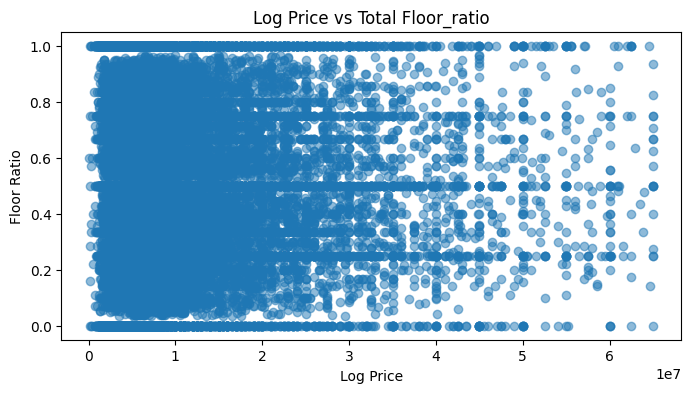

In [1061]:
plt.figure(figsize=(8,4))
plt.scatter(y, X["floor_ratio"], alpha=0.5)
plt.title("Log Price vs Total Floor_ratio")
plt.xlabel("Log Price")
plt.ylabel("Floor Ratio")
plt.show()

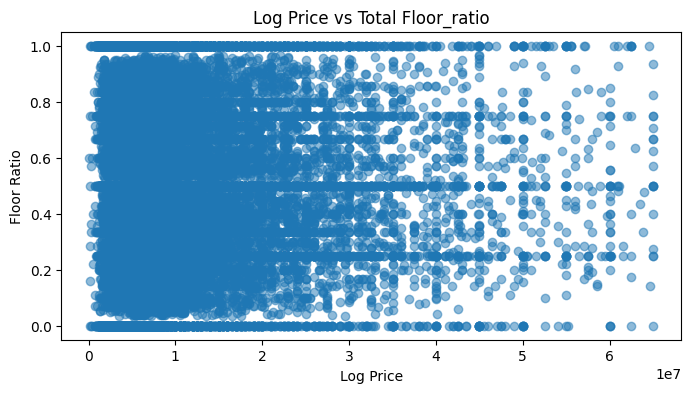

In [1062]:
plt.figure(figsize=(8,4))
plt.scatter(y, X["floor_ratio"], alpha=0.5)
plt.title("Log Price vs Total Floor_ratio")
plt.xlabel("Log Price")
plt.ylabel("Floor Ratio")
plt.show()


A new feature, `floor_ratio`, was created as:

floor_ratio = Current_floor / Total_floor

Scatter plot analysis showed no strong linear relationship between floor ratio and property price. The values were widely distributed across different price ranges, suggesting that floor ratio alone may not be a strong predictor of property price.

However, the feature was retained for modeling, as tree-based algorithms may still capture non-linear relationships.

In [1063]:
X.isnull().sum()/X.shape[0]*100

location             0.000000
Transaction          0.145577
Furnishing           0.061142
facing              19.894602
overlooking         24.678274
Bathroom             0.034939
Balcony              6.382111
Ownership           17.245094
Bhk                  0.384324
Carpet_area_sqft     0.000000
Current_floor        0.000000
Total_floor          0.000000
floor_ratio          0.002912
dtype: float64

In [1116]:
num_cols = X.select_dtypes(include=["float64", "int64"]).columns.to_list()
cat_cols = X.select_dtypes(include=["object"]).columns.to_list()
num_cols1 = X[num_cols]
cat_cols1 = X[cat_cols]

In [1117]:
num_cols1.skew()

Bathroom            0.833062
Balcony             0.930222
Bhk                 0.103795
Carpet_area_sqft    1.125627
Current_floor       2.055992
Total_floor         1.388521
floor_ratio         0.099774
dtype: float64

In [1118]:
y.skew()

np.float64(2.5378752496640216)

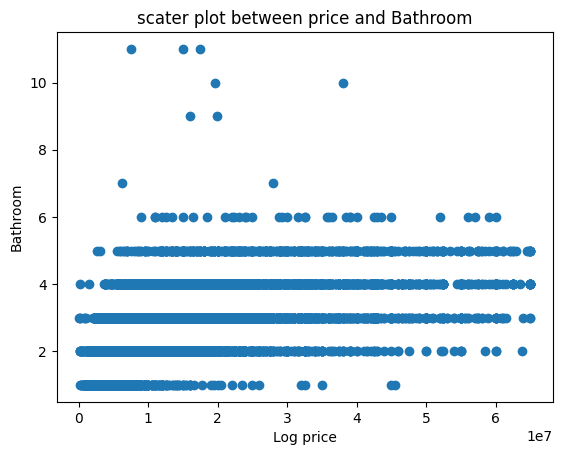

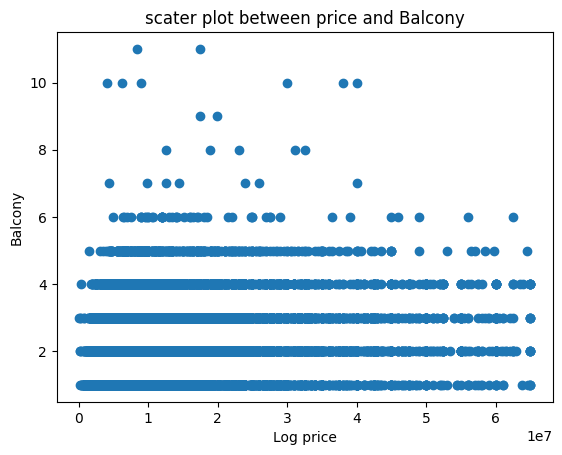

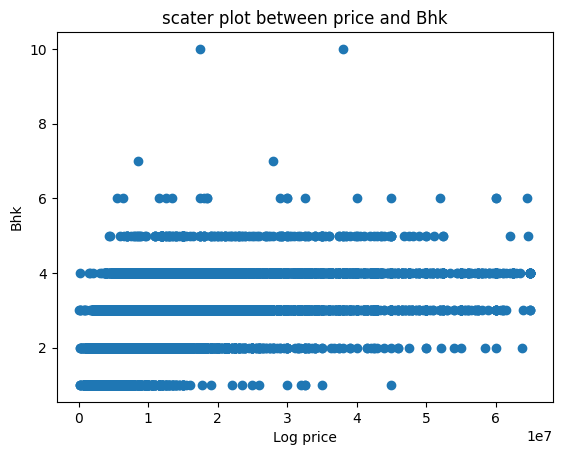

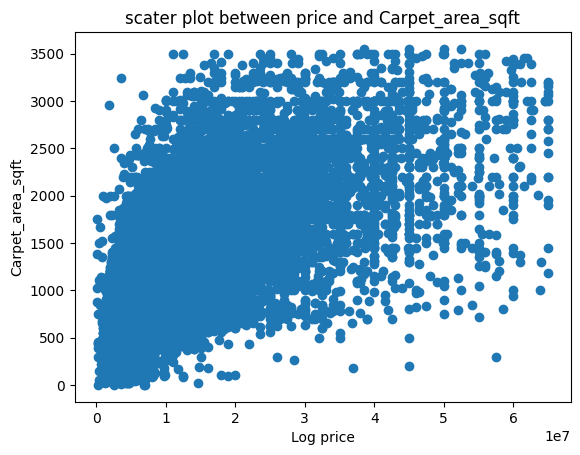

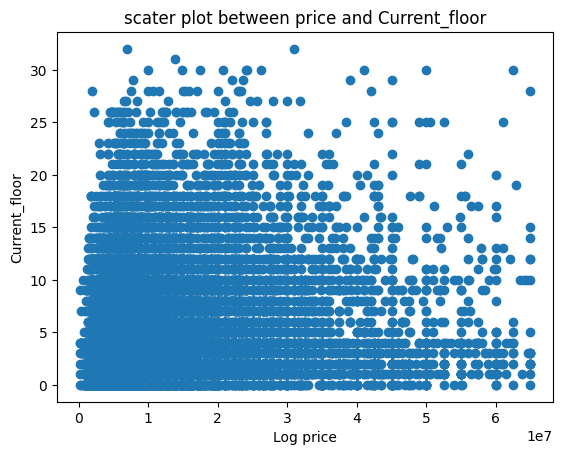

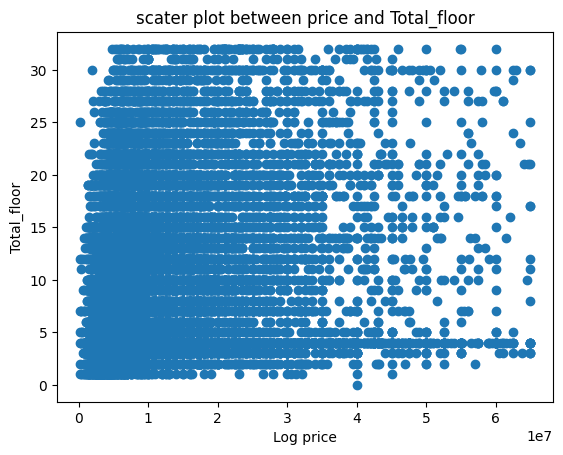

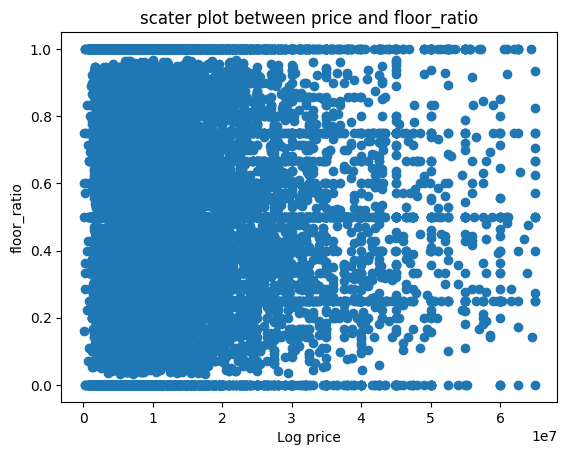

In [1065]:
for col in X[num_cols]:
    plt.scatter(y,X[col])
    plt.title(f"scater plot between price and {col}")
    plt.xlabel("Log price")
    plt.ylabel(col)
    plt.show()

"Most numerical features exhibit a positive relationship with property price. Features such as Carpet Area, BHK, Bathroom count, and Balcony tend to increase with price. However, Current Floor, Total Floor, and Floor Ratio show a relatively weak relationship with the target variable."

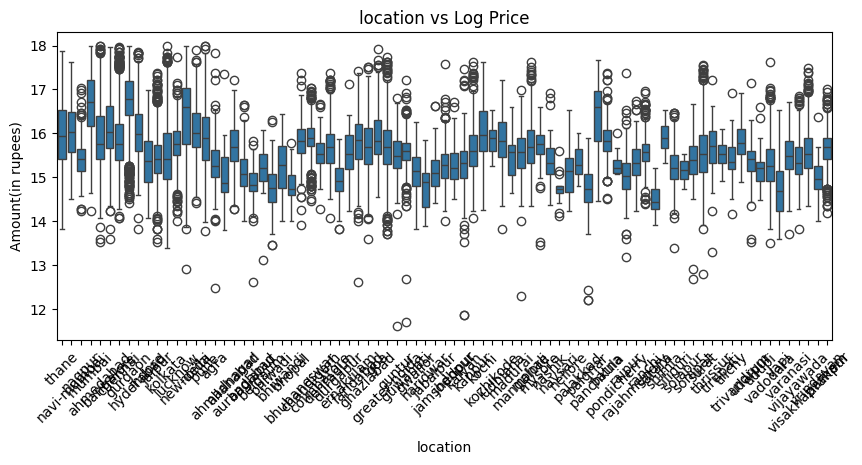

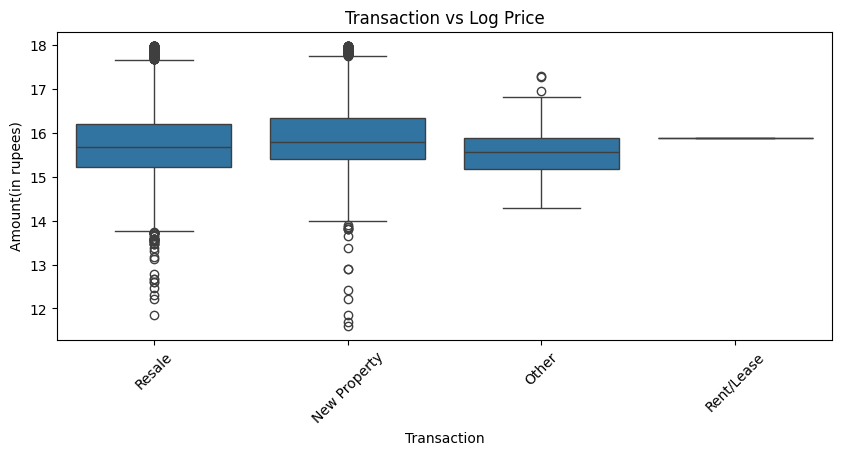

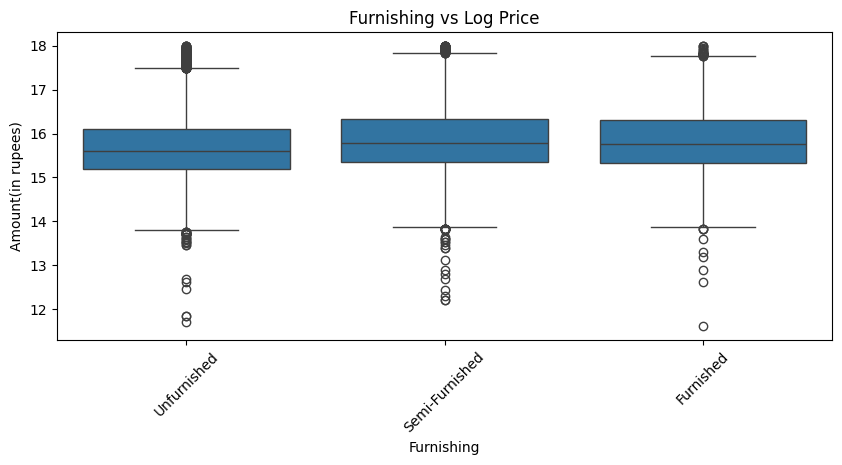

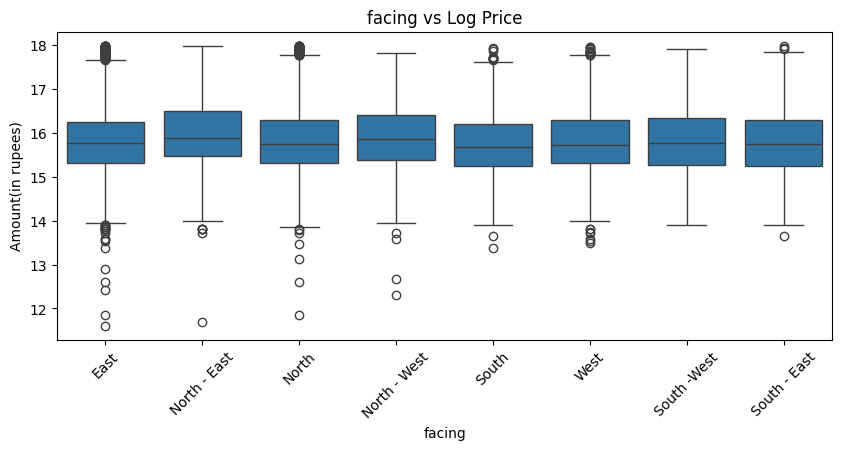

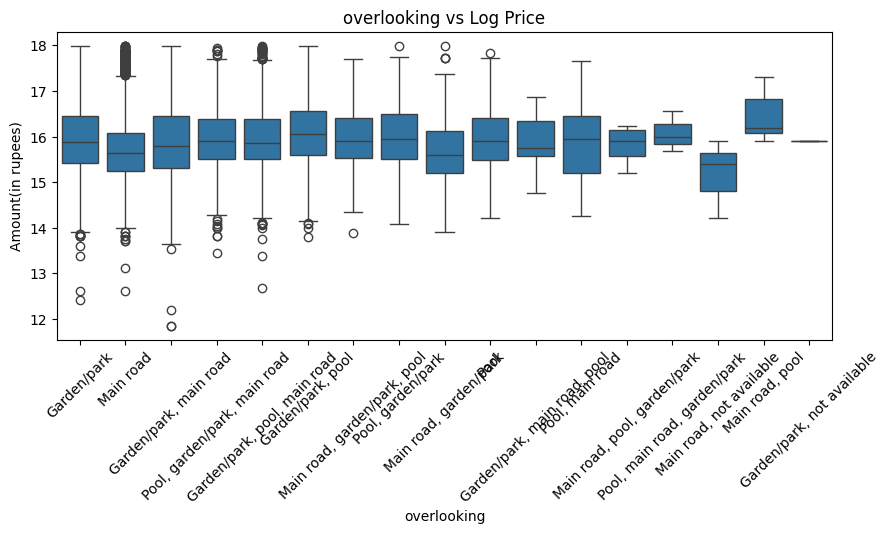

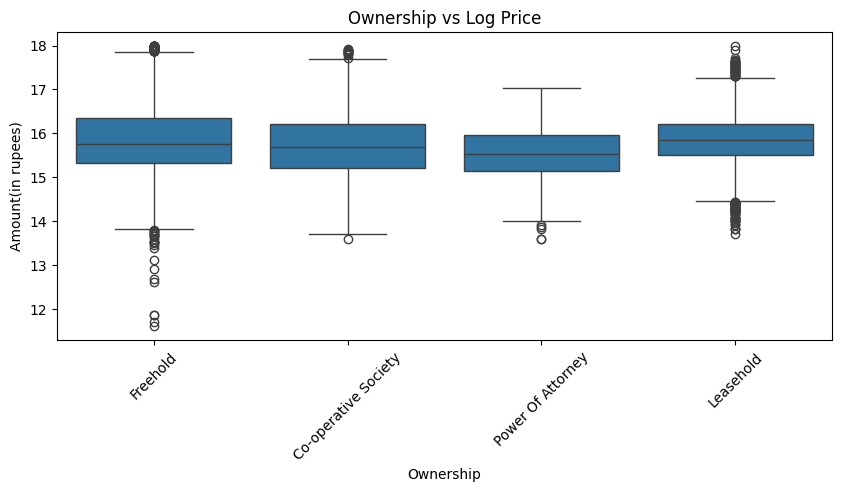

In [1066]:
for col in X[cat_cols]:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=X[col], y=np.log1p(y))
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Log Price")
    plt.show()

In [1067]:
corr_with_price = X[num_cols].corrwith(np.log1p(y))

corr_with_price.sort_values(ascending=False)

Carpet_area_sqft    0.702746
Bathroom            0.660211
Bhk                 0.642481
Balcony             0.290556
Total_floor         0.271228
Current_floor       0.204372
floor_ratio        -0.036844
dtype: float64

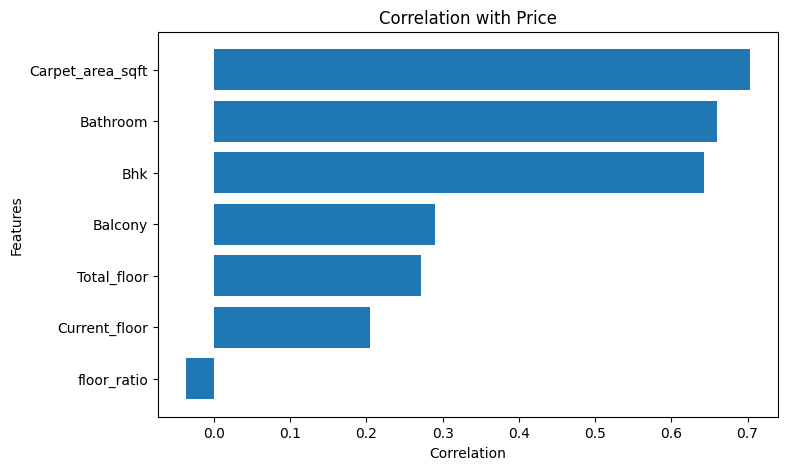

In [1068]:
corr_sorted = corr_with_price.sort_values()

plt.figure(figsize=(8,5))
plt.barh(corr_sorted.index, corr_sorted.values)
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.title("Correlation with Price")
plt.show()

In [1069]:
corr_matrix = X[num_cols].corr()

corr_matrix

,Bathroom,Balcony,Bhk,Carpet_area_sqft,Current_floor,Total_floor,floor_ratio
Bathroom,1.000000,0.395695,0.807786,0.756231,0.132059,0.171945,-0.021477
Balcony,0.395695,1.000000,0.366546,0.350690,0.191103,0.259585,-0.013802
Bhk,0.807786,0.366546,1.000000,0.759961,0.071439,0.092150,-0.018611
Carpet_area_sqft,0.756231,0.350690,0.759961,1.000000,0.065465,0.078116,-0.011131
Current_floor,0.132059,0.191103,0.071439,0.065465,1.000000,0.731043,0.455190
Total_floor,0.171945,0.259585,0.092150,0.078116,0.731043,1.000000,-0.093445
floor_ratio,-0.021477,-0.013802,-0.018611,-0.011131,0.455190,-0.093445,1.000000


In [1070]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = X[num_cols].fillna(X[num_cols].median())
for i in range(X_vif.shape[1]):
    vif = variance_inflation_factor(X_vif.values, i)
    print(X_vif.columns[i],round(vif, 2))


Bathroom 32.24
Balcony 7.03
Bhk 33.04
Carpet_area_sqft 15.42
Current_floor 8.74
Total_floor 9.03
floor_ratio 6.57


Multicollinearity Analysis


VIF analysis revealed multicollinearity among several numerical features, particularly BHK, Bathroom, and Carpet Area. This is expected in real estate datasets, as larger properties generally contain more rooms and bathrooms. Despite the observed multicollinearity, all features were retained for model training and evaluated using both linear and tree-based algorithms.

### Correlation Analysis

Bathroom (0.693), BHK (0.667), and Carpet Area (0.659) exhibit the strongest positive correlations with property price. Balcony and Total Floor show moderate positive relationships, while Current Floor demonstrates a weak association. Floor Ratio exhibits negligible correlation with the target variable, indicating limited linear predictive power.

In [1071]:

X[num_cols].describe().round(0).T

,count,mean,std,min,25%,50%,75%,max
Bathroom,34334.0,2.0,1.0,1.0,2.0,2.0,3.0,11.0
Balcony,32154.0,2.0,1.0,1.0,1.0,2.0,3.0,11.0
Bhk,34214.0,3.0,1.0,1.0,2.0,3.0,3.0,10.0
Carpet_area_sqft,34346.0,1180.0,543.0,1.0,800.0,1090.0,1450.0,3550.0
Current_floor,34346.0,4.0,4.0,0.0,2.0,3.0,5.0,32.0
Total_floor,34346.0,8.0,6.0,0.0,4.0,5.0,12.0,32.0
floor_ratio,34345.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0


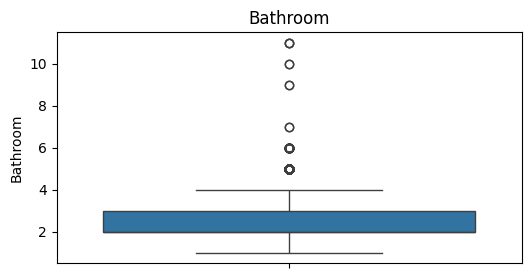

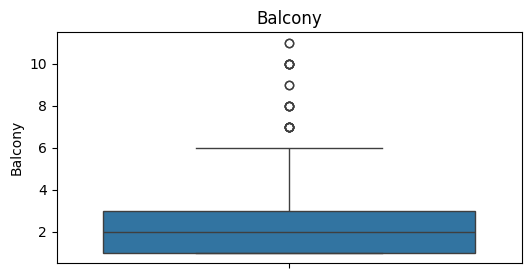

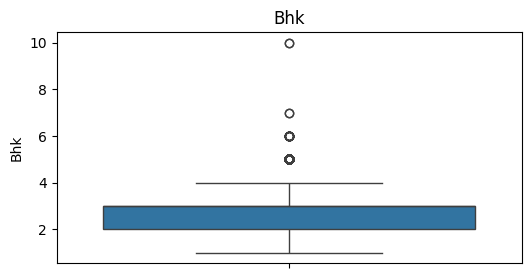

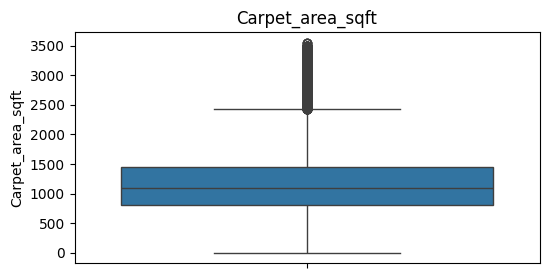

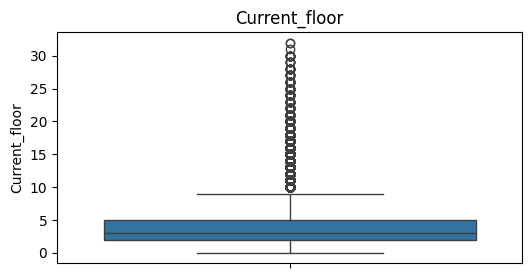

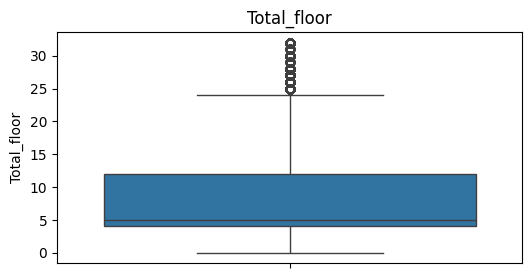

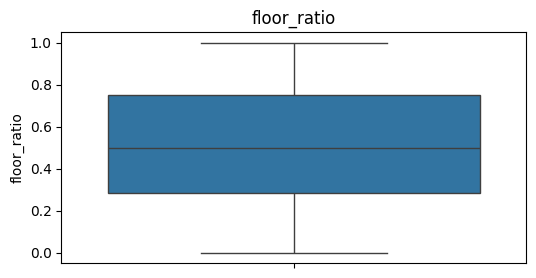

In [1072]:

for col in X[num_cols]:
     plt.figure(figsize=(6, 3))
     sns.boxplot(X[col])
     plt.title(col)
     plt.show()

Although the boxplot identified several observations as outliers using the IQR rule, domain analysis showed that these values were genuine large properties rather than data errors. Therefore, instead of removing them, I have applied a log transformation on Carpet area sqft to reduce skewness and the influence of extreme values.

Train Test Split

In [1073]:
X_train, X_test, y_train,y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)


In [1074]:
X_train_num =X_train.select_dtypes(include=["float64","int64"]).columns.to_list()
X_train_cat =X_train.select_dtypes(include=["object", "string"]).columns.to_list()



Column Transformer

In [1075]:
print("Numerical:", X_train_num)
print("Categorical:", X_train_cat)

Numerical: ['Bathroom', 'Balcony', 'Bhk', 'Carpet_area_sqft', 'Current_floor', 'Total_floor', 'floor_ratio']
Categorical: ['location', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Ownership']


In [1076]:

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])



In [1077]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [1078]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, X_train_num),
    ("cat", cat_pipeline, X_train_cat)
])


In [1132]:
y.skew()

np.float64(2.5378752496640216)

### Target Variable Transformation

The target variable was found to be highly right-skewed (**skewness = 2.54**). To reduce the effect of extreme house prices, a logarithmic transformation (`log1p`) was applied to the target variable before training the model. During prediction, the transformed values were converted back to the original scale using `expm1` to evaluate the model with real house prices.

Although the log transformation slightly reduced the Mean Absolute Error (MAE), it did not improve the overall predictive performance, as the R² Score decreased marginally and the RMSE increased. Therefore, the original target variable was retained for the final XGBoost model.

In [1127]:
y_train_log = np.log1p(y_train)

In [1131]:
print("="*60)
print("Models With Log")
print("="*60)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Extra_tree": ExtraTreesRegressor(random_state= 42, n_estimators=200, n_jobs= -1),
    "Xgboost" : XGBRegressor(
    n_estimators=200,
    learning_rate=0.04,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs = -1
)
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    y_train_log = np.log1p(y_train)
    pipeline.fit(X_train, y_train_log)

    y_pred = pipeline.predict(X_test)
    y_pred = np.expm1(y_pred)

    results.append({
        "Model": name,
        "R2": round(r2_score(y_test, y_pred), 4),
        "MAE": round(mean_absolute_error(y_test, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R2",
    ascending=False
)
for name, model in models.items():
    pipeline =Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipeline.fit(X_train, y_train)

Models With Log


,Model,R2,MAE,RMSE
5,Extra_tree,0.7957,2.227986e+06,4.118527e+06
6,Xgboost,0.7897,2.286332e+06,4.179435e+06
2,Random Forest,0.7848,2.292012e+06,4.227237e+06
4,SVR,0.7838,2.300575e+06,4.237730e+06
0,Linear Regression,0.6697,2.784659e+06,5.237028e+06
3,KNN,0.6478,2.925335e+06,5.408223e+06
1,Decision Tree,0.6448,2.998999e+06,5.431571e+06


In [1129]:
print("="*60)
print("Models Without Log")
print("="*60)
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Extra_tree": ExtraTreesRegressor(random_state= 42, n_estimators=200, n_jobs= -1),
    "Xgboost" : XGBRegressor(
    n_estimators=200,
    learning_rate=0.04,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs = -1
)
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "R2": round(r2_score(y_test, y_pred), 4),
        "MAE": round(mean_absolute_error(y_test, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R2",
    ascending=False
)

Models Without Log


,Model,R2,MAE,RMSE
6,Xgboost,0.8020,2.324250e+06,4.054813e+06
5,Extra_tree,0.7956,2.290998e+06,4.119780e+06
2,Random Forest,0.7946,2.321137e+06,4.129764e+06
0,Linear Regression,0.6882,3.221140e+06,5.088780e+06
3,KNN,0.6654,2.972938e+06,5.271231e+06
1,Decision Tree,0.6104,3.085892e+06,5.687929e+06
4,SVR,-0.1189,5.475488e+06,9.639712e+06


# Model Comparison: With vs Without Log Transformation

## Objective

The target variable (`Amount (in rupees)`) showed a highly right-skewed distribution during Exploratory Data Analysis (EDA). To determine whether transforming the target variable would improve model performance, two experiments were conducted:

1. **Without Log Transformation**
2. **With Log Transformation (`log1p`)**

Both experiments used the same preprocessing pipeline, train-test split, and evaluation metrics to ensure a fair comparison.

---

# Results Without Log Transformation

| Model | R² | MAE | RMSE |
|------|----:|----:|-----:|
| XGBoost | **0.8020** | 2,324,250 | 4,054,813 |
| Extra Trees | 0.7956 | 2,290,998 | 4,119,780 |
| Random Forest | 0.7946 | 2,321,137 | 4,129,764 |
| Linear Regression | 0.6882 | 3,221,140 | 5,088,780 |
| KNN | 0.6654 | 2,972,938 | 5,271,231 |
| Decision Tree | 0.6104 | 3,085,892 | 5,687,929 |
| SVR | -0.1189 | 5,475,488 | 9,639,712 |

---

# Results With Log Transformation

| Model | R² | MAE | RMSE |
|------|----:|----:|-----:|
| Extra Trees | **0.7957** | 2,227,986 | 4,118,527 |
| XGBoost | 0.7897 | 2,286,332 | 4,179,435 |
| Random Forest | 0.7848 | 2,292,012 | 4,227,237 |
| SVR | 0.7838 | 2,300,575 | 4,237,730 |
| Linear Regression | 0.6697 | 2,784,659 | 5,237,028 |
| KNN | 0.6478 | 2,925,335 | 5,408,223 |
| Decision Tree | 0.6448 | 2,998,999 | 5,431,571 |

---

# Observations

- Log transformation successfully reduced the skewness of the target variable.
- Tree-based models (XGBoost, Extra Trees, and Random Forest) performed well in both experiments.
- XGBoost achieved the highest R² score (**0.8020**) without log transformation.
- Extra Trees performed almost identically with and without log transformation.
- SVR benefited significantly from log transformation, while XGBoost and Random Forest showed only marginal differences.

---

# Final Model Selection

**Selected Model:** XGBoost Regressor

### Reasons for Selection

- Highest Test R² Score (**0.8020**)
- Competitive MAE and RMSE
- Strong generalization performance
- Robust against non-linear relationships
- Suitable for deployment in the Streamlit application

---

# Conclusion

Although the target variable was highly skewed and log transformation was evaluated as a potential improvement, experimental results showed that **XGBoost trained on the original target variable produced the best overall performance**. Therefore, the final deployed model uses the original target values without log transformation.

## Hyperparameter Tuning
   using RandomizedSearch:

In [1133]:

param_dist = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [3, 5, 7, 9],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.3, 0.5],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [1, 3, 5]
}

In [1135]:
Xgb_pipe = Pipeline([("preprocessor", preprocessor), ("model", XGBRegressor())])

In [1137]:
random_search = RandomizedSearchCV(
    estimator=Xgb_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.6, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies 

In [1138]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.8046415038845991
MAE: 2307285.5171852256
RMSE: 4027876.124312976


# Hyperparameter Tuning

## Objective

After comparing multiple machine learning models, **XGBoost Regressor** was selected as the best-performing model. Hyperparameter tuning was performed using **RandomizedSearchCV with 5-fold Cross Validation** to improve its predictive performance.

## Results

- **R² Score:** Improved from **0.8020** to **0.8046**
- **MAE:** Reduced from **2,324,250** to **2,307,286**
- **RMSE:** Reduced from **4,054,813** to **4,027,876**

## Conclusion

Hyperparameter tuning provided a small but consistent improvement in model performance. The tuned XGBoost model achieved the highest R² score with lower prediction errors, making it the final model selected for deployment.

# Cross Validation

In [1139]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("CV Scores:", scores)
print("Mean CV R2:", scores.mean())
print("Std:", scores.std())

CV Scores: [0.81260022 0.8062549  0.80122898 0.80786004 0.80287432]
Mean CV R2: 0.806163689202321
Std: 0.003987132282756861


# Cross Validation

**Mean CV R² Score:** **0.8062**  
**Standard Deviation:** **0.0040**

**Conclusion:** The low standard deviation indicates consistent model performance across all folds, demonstrating good generalization and minimal overfitting.

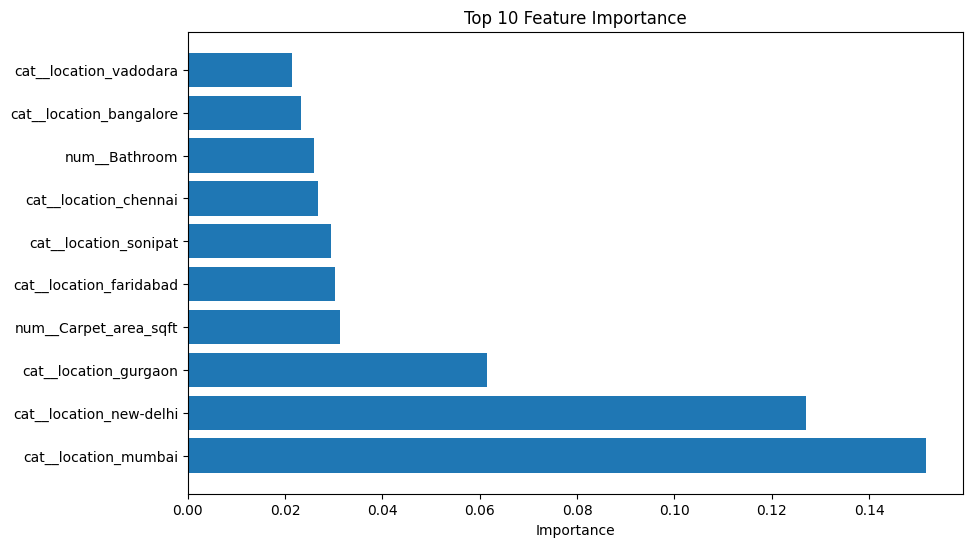

In [1143]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importance = best_model.named_steps["model"].feature_importances_

# Create DataFrame
feature_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_imp = feature_imp.sort_values(by="Importance", ascending=False)

# Top 15 features
plt.figure(figsize=(10,6))
plt.barh(feature_imp["Feature"][:10], feature_imp["Importance"][:10])

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.show()

# Feature Importance

## Objective

Feature importance analysis was performed to identify the variables that contributed most to house price prediction.

## Observations

- **Location** was the most influential feature, with cities such as **Mumbai**, **New Delhi**, and **Gurgaon** having the highest importance.
- **Carpet Area** was one of the most significant numerical features affecting house prices.
- **Bathroom count** also contributed to the model's predictions, though to a lesser extent.
- Overall, both **location-based** and **property-specific** features played an important role in predicting house prices.

## Conclusion

The feature importance analysis indicates that **location is the strongest driver of house prices**, followed by **carpet area** and other property characteristics. This aligns with real-world real estate trends and improves the interpretability of the model.

# Model dumping using Joblib

In [1]:
jb.dump(best_model, "house_price_model.pkl")

print("Model saved successfully!")

NameError: name 'jb' is not defined